In [37]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# loading the dataset using pandas

df = pd.read_csv(r"C:\Users\DELL\OneDrive\Project\Telco-Customer-Churn.csv")
pd.set_option('display.max_columns', None)
df.head()

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [40]:
# summary statistics

df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [41]:
# checking unique values

df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [42]:
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [43]:
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [44]:
# converting datatype

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [45]:
df["TotalCharges"].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [46]:
# checking duplicate data in dataset

df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [47]:
# checking null values

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [48]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [49]:
# filling null values with 0 as the where the total charges are null the tenure was 0 

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [50]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [51]:
# changing rows from CamelCase to snake_case

df.columns = df.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex = True).str.lower()
df.columns

Index(['customer_i_d', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_t_v', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [52]:
df.columns = df.columns.str.replace("customer_i_d","customer_id")
df.columns = df.columns.str.replace("streaming_t_v","streaming_tv")
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [53]:
# turning string cols to numeric cols for better analysis

df["partner"] = df["partner"].map({"Yes":1,"No":0}).astype(int)
df["dependents"] = df["dependents"].map({"Yes":1,"No":0}).astype(int)
df["phone_service"] = df["phone_service"].map({"Yes":1,"No":0}).astype(int)
df["paperless_billing"] = df["paperless_billing"].map({"Yes":1,"No":0}).astype(int)
df["churn"] = df["churn"].map({"Yes":1,"No":0}).astype(int)
df["contract_type"] = df["contract"].map({"Month-to-month":0, "One year":1, "Two year":2})

In [54]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,contract_type
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0,1
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,1
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0


In [55]:
df["tenure"].max()

np.int64(72)

In [56]:
# creating a new col tenure_group

labels = ["New","Reliable","Established","Loyal"]
bins = [0,12,24,48,72]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels = labels, include_lowest=True)

In [57]:
df[["tenure","tenure_group"]].head(10)

,tenure,tenure_group
0,1,New
1,34,Established
2,2,New
3,45,Established
4,2,New
5,8,New
6,22,Reliable
7,10,New
8,28,Established
9,62,Loyal


In [58]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,contract_type,tenure_group
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0,New
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0,1,Established
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0,New
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,1,Established
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0,New


In [59]:
# creating new col total_services_count, has_additional services & only_phone_services

service_cols = ["multiple_lines", "online_security", "online_backup", "device_protection", "tech_support", "streaming_tv", 
             "streaming_movies"]

# Create a new column that sums the 'Yes' values
df['total_services_count'] = df[service_cols].apply(lambda x: x == "Yes").sum(axis=1)

# a binary "Has Multiple Services" (1 if count > 0, else 0)
df['has_additional_services'] = (df['total_services_count'] > 0).astype(int)

df["only_phone_service"] = np.where((df["has_additional_services"] == 0) & (df["internet_service"] == "No"),1,0)

In [60]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,contract_type,tenure_group,total_services_count,has_additional_services,only_phone_service
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0,New,1,1,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0,1,Established,2,1,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0,New,2,1,0
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,1,Established,3,1,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0,New,0,0,0


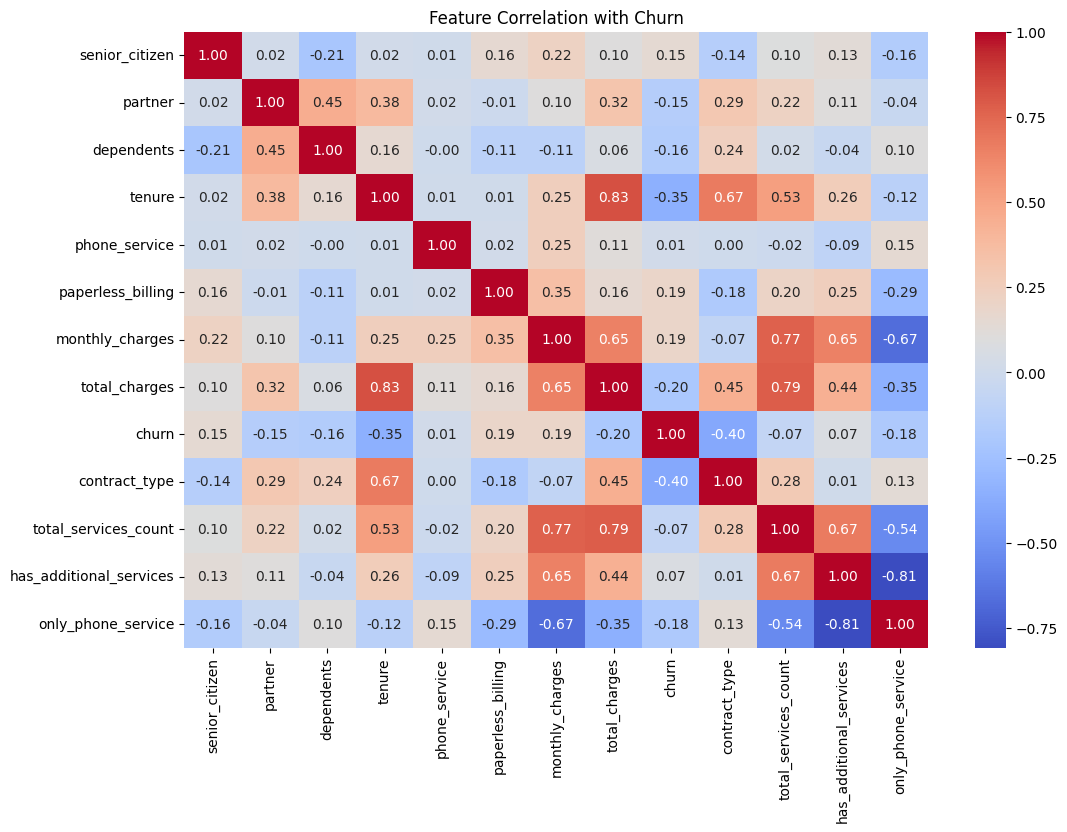

In [61]:
# checking the correlation between numeric values with the help of heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include = "number").corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Feature Correlation with Churn")
plt.show()

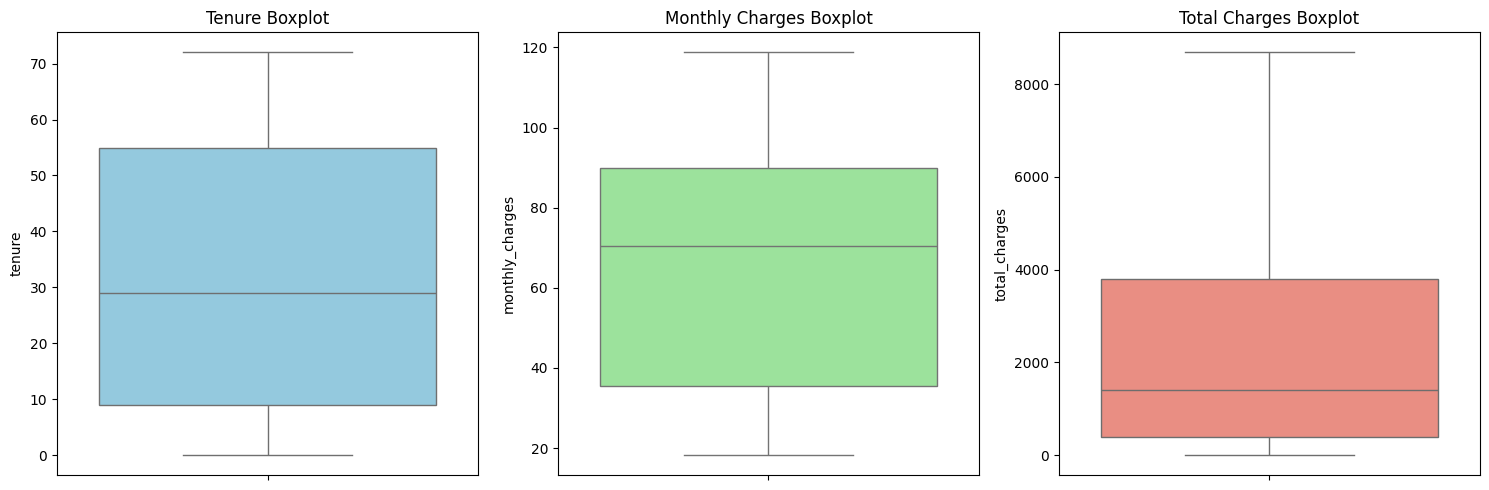

In [62]:
# checking the outliers with the help of box plot

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['tenure'], color='skyblue')
plt.title('Tenure Boxplot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['monthly_charges'], color='lightgreen')
plt.title('Monthly Charges Boxplot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['total_charges'], color='salmon')
plt.title('Total Charges Boxplot')

plt.tight_layout()
plt.show()

In [63]:
# arranging the order of cols

new_order = ["customer_id", "churn", "gender", "senior_citizen", "partner", "dependents", "tenure", "tenure_group", "phone_service", 
             "multiple_lines", "internet_service", "online_security", "online_backup", "device_protection", "tech_support", "streaming_tv", 
             "streaming_movies", "total_services_count", "only_phone_service", "has_additional_services", "contract", "contract_type", "paperless_billing", "payment_method", "monthly_charges", "total_charges"]
df = df[new_order]
df.head()

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,tenure_group,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,total_services_count,only_phone_service,has_additional_services,contract,contract_type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,0,Female,0,1,0,1,New,0,No phone service,DSL,No,Yes,No,No,No,No,1,0,1,Month-to-month,0,1,Electronic check,29.85,29.85
1,5575-GNVDE,0,Male,0,0,0,34,Established,1,No,DSL,Yes,No,Yes,No,No,No,2,0,1,One year,1,0,Mailed check,56.95,1889.50
2,3668-QPYBK,1,Male,0,0,0,2,New,1,No,DSL,Yes,Yes,No,No,No,No,2,0,1,Month-to-month,0,1,Mailed check,53.85,108.15
3,7795-CFOCW,0,Male,0,0,0,45,Established,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,3,0,1,One year,1,0,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,1,Female,0,0,0,2,New,1,No,Fiber optic,No,No,No,No,No,No,0,0,0,Month-to-month,0,1,Electronic check,70.70,151.65


In [64]:
pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
# importing cleaned dataset to sql for further analysis

from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "123456789"
host = "localhost"
port = "3306"
database = "project"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "subscription_churn"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM subscription_churn LIMIT 5;", engine)

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,tenure_group,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,total_services_count,only_phone_service,has_additional_services,contract,contract_type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,0,Female,0,1,0,1,New,0,No phone service,DSL,No,Yes,No,No,No,No,1,0,1,Month-to-month,0,1,Electronic check,29.85,29.85
1,5575-GNVDE,0,Male,0,0,0,34,Established,1,No,DSL,Yes,No,Yes,No,No,No,2,0,1,One year,1,0,Mailed check,56.95,1889.50
2,3668-QPYBK,1,Male,0,0,0,2,New,1,No,DSL,Yes,Yes,No,No,No,No,2,0,1,Month-to-month,0,1,Mailed check,53.85,108.15
3,7795-CFOCW,0,Male,0,0,0,45,Established,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,3,0,1,One year,1,0,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,1,Female,0,0,0,2,New,1,No,Fiber optic,No,No,No,No,No,No,0,0,0,Month-to-month,0,1,Electronic check,70.70,151.65
